# Machine Learning Regression Model

In [2]:
???

Object `?` not found.


Classification Model | Regression Model
-|-
![](src/pred_classification.png) | ![](src/pred_regression.png)

## [ ] Load the data

In [3]:
import pandas as pd

df = pd.read_excel('data/Microsoft_LinkedIn_Processed.xlsx', parse_dates=['Date'], index_col=0)
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,61.009998,61.580002,60.840000,61.299999,21220800,1.549141,UP
2016-12-09,61.970001,61.990002,61.130001,61.180000,27349400,0.321694,UP
2016-12-12,62.169998,62.299999,61.720001,61.820000,20198100,1.286125,UP
2016-12-13,62.980000,63.419998,62.240002,62.500000,35718900,-0.478620,DOWN
2016-12-14,62.680000,63.450001,62.529999,63.000000,30352700,-0.159793,DOWN
...,...,...,...,...,...,...,...
2026-05-14,409.429993,411.839996,400.880005,404.480011,27077500,2.960282,UP
2026-05-15,421.920013,428.170013,412.910004,414.269989,50771200,0.382489,UP
2026-05-18,423.540009,425.119995,415.609985,416.619995,32564100,-1.466148,DOWN


## Machine Learning Model

### Separate the data

1. Target: which variable do you want to predict?
2. Explanatory: which variables will you use to calculate the prediction?

In [4]:
target = df.change_tomorrow
explanatory = df[['Open','High','Low','Close','Volume']]

In [8]:
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,61.009998,61.580002,60.840000,61.299999,21220800,1.549141,UP
2016-12-09,61.970001,61.990002,61.130001,61.180000,27349400,0.321694,UP
2016-12-12,62.169998,62.299999,61.720001,61.820000,20198100,1.286125,UP
2016-12-13,62.980000,63.419998,62.240002,62.500000,35718900,-0.478620,DOWN
2016-12-14,62.680000,63.450001,62.529999,63.000000,30352700,-0.159793,DOWN
...,...,...,...,...,...,...,...
2026-05-14,409.429993,411.839996,400.880005,404.480011,27077500,2.960282,UP
2026-05-15,421.920013,428.170013,412.910004,414.269989,50771200,0.382489,UP
2026-05-18,423.540009,425.119995,415.609985,416.619995,32564100,-1.466148,DOWN


In [6]:
explanatory

,Open,High,Low,Close,Volume
Date,,,,,
2016-12-08,61.299999,61.580002,60.840000,61.009998,21220800
2016-12-09,61.180000,61.990002,61.130001,61.970001,27349400
2016-12-12,61.820000,62.299999,61.720001,62.169998,20198100
2016-12-13,62.500000,63.419998,62.240002,62.980000,35718900
2016-12-14,63.000000,63.450001,62.529999,62.680000,30352700
...,...,...,...,...,...
2026-05-14,404.480011,411.839996,400.880005,409.429993,27077500
2026-05-15,414.269989,428.170013,412.910004,421.920013,50771200
2026-05-18,416.619995,425.119995,415.609985,423.540009,32564100


### Compute the model

The following model will predict the **numerical increase** of the stock for the following day.

As the variable we predict is numerical, we talk about regression models. In the previous tutorial, we used a classification model since the variable we predicted was categorical (UP or DOWN).

In [9]:
from sklearn.tree import DecisionTreeRegressor

In [15]:
model_dt = DecisionTreeRegressor(max_depth=15)

In [16]:
model_dt.fit(X=explanatory, y=target)

DecisionTreeRegressor(max_depth=15)

### Calculate the predictions

[Text(0.9372406639004149, 0.96875, 'Volume <= 92951148.0\nsquared_error = 2.977\nsamples = 2374\nvalue = 0.066'),
 Text(0.8900414937759336, 0.90625, 'Volume <= 91578148.0\nsquared_error = 2.892\nsamples = 2369\nvalue = 0.06'),
 Text(0.9136410788381742, 0.9375, 'True  '),
 Text(0.8872752420470262, 0.84375, 'Volume <= 87003952.0\nsquared_error = 2.766\nsamples = 2368\nvalue = 0.067'),
 Text(0.803941908713693, 0.78125, 'Volume <= 78979100.0\nsquared_error = 2.744\nsamples = 2366\nvalue = 0.063'),
 Text(0.6455739972337483, 0.71875, 'Volume <= 78738752.0\nsquared_error = 2.729\nsamples = 2357\nvalue = 0.071'),
 Text(0.642807745504841, 0.65625, 'Low <= 417.82\nsquared_error = 2.702\nsamples = 2356\nvalue = 0.067'),
 Text(0.4205999308437068, 0.59375, 'Volume <= 46535200.0\nsquared_error = 2.784\nsamples = 2038\nvalue = 0.102'),
 Text(0.27035788381742737, 0.53125, 'Volume <= 35686850.0\nsquared_error = 2.454\nsamples = 1900\nvalue = 0.124'),
 Text(0.169432918395574, 0.46875, 'Volume <= 3399550

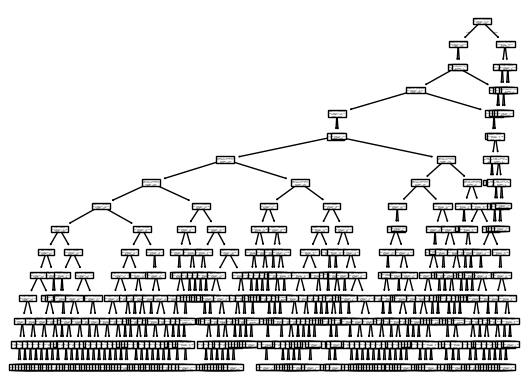

In [17]:
from sklearn.tree import plot_tree

plot_tree(decision_tree=model_dt, feature_names=model_dt.feature_names_in_)

### Evaluate the model: compare predictions with the reality

In [20]:
y_pred=model_dt.predict(X=explanatory)

## [ ] How to interpret the error?

In [21]:
df_predictions = df[['change_tomorrow']].copy()

df_predictions['prediction'] = y_pred
df_predictions

,change_tomorrow,prediction
Date,,
2016-12-08,1.549141,0.103739
2016-12-09,0.321694,0.412775
2016-12-12,1.286125,0.103739
2016-12-13,-0.478620,-0.478620
2016-12-14,-0.159793,0.270346
...,...,...
2026-05-14,2.960282,0.300795
2026-05-15,0.382489,0.462531
2026-05-18,-1.466148,-1.646820


In [23]:
model_dt.score(X=explanatory, y=target)

0.455743645892541

In [25]:
df_predictions.prediction - df_predictions.change_tomorrow

Date
2016-12-08   -1.445402
2016-12-09    0.091081
2016-12-12   -1.182386
2016-12-13    0.000000
2016-12-14    0.430139
                ...   
2026-05-14   -2.659487
2026-05-15    0.080041
2026-05-18   -0.180672
2026-05-19   -0.978435
2026-05-20    0.770861
Length: 2374, dtype: float64

In [26]:
df_predictions['error'] = df_predictions.prediction - df_predictions.change_tomorrow

In [29]:
df_predictions.error.sum().round(2)

np.float64(-0.0)

In [31]:
df_predictions['error2'] = df_predictions.error**2

In [36]:
sse= df_predictions.error2.sum()

In [38]:
mse=df_predictions.error2.mean()

In [40]:
import numpy as np

In [42]:
rmse= np.sqrt(mse)

In [43]:
rmse

np.float64(1.2728782572926214)

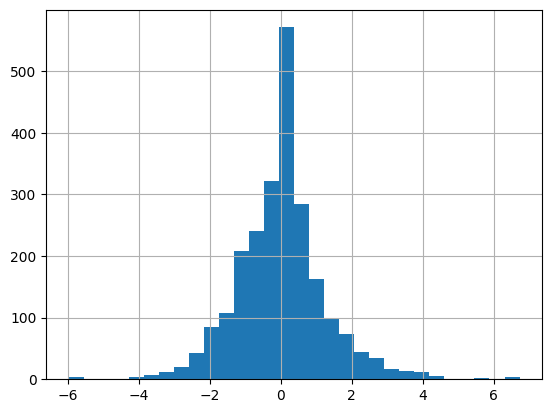

In [44]:
df_predictions.error.hist(bins=30);

The Standard Deviation of the Error|The Normal Distribution
-|-
![](src/std.png) | ![](src/std_normal.png)

source: wikipedia

## Save the model into a file

- We'll write the numbers of the Decision Tree's mathematical equation into a file.

In [45]:
import pickle

In [46]:
model_dt

DecisionTreeRegressor(max_depth=15)

In [47]:
with open('models/model_dt_regression.pkl', 'wb') as f:
    pickle.dump(model_dt, f)